# Phenology comparison across crops — flowering & maturity

Compare **observed vs simulated** flowering (anthesis) and maturity for all five
calibrated crops in a single notebook, using the baseline DWD simulation on soil
scenario **S1**.

The simulation selection is fully flexible: change `SIM_NAME` below to any run
folder under `<crop>/runs/` (e.g. `DWD__S2`, `DWD__S3`, `SMOKE_DWD__S1`, or a
future climate run) and re-run the notebook to see how the phenology optimization
looks for that scenario.


## Configuration


In [1]:
import os
from concurrent.futures import ThreadPoolExecutor
from glob import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

plt.rcParams["font.family"] = "DeJavu Serif"
plt.rcParams["font.serif"] = "Times New Roman"

# ---------------------------------------------------------------------------
# Flexible selection: edit these to change what is compared.
# ---------------------------------------------------------------------------
# Root that holds one folder per crop.
# --- Repo-relative paths ---------------------------------------------------
# Resolved from this notebook's location, so the checkout can be moved or cloned
# anywhere without editing paths here. Override with SOIL_SCENARIOS_ROOT.
import os
from pathlib import Path


def _find_repo_root(start=None):
    env = os.environ.get("SOIL_SCENARIOS_ROOT")
    if env:
        return Path(env).expanduser().resolve()
    here = Path(start or Path.cwd()).resolve()
    for cand in (here, *here.parents):
        if (cand / "simplace").is_dir() and (cand / "orchestration").is_dir():
            return cand
    raise FileNotFoundError(
        f"repo root not found from {here} (looked for simplace/ + orchestration/)"
    )


REPO_ROOT = _find_repo_root()

# Root that holds one folder per crop.
BASE_DIR = REPO_ROOT / "simplace"

# The simulation / run to evaluate. This is the run-folder name under
# `<crop>/runs/`. Swap it to compare a different soil scenario or climate run,
# e.g. "DWD__S2", "DWD__S3", "DWD__DL", "DWD__DLB", "SMOKE_DWD__S1".
SIM_NAME = "DWD__S1"

# Crops to include (must match the folder names under `simplace/`).
CROPS = ["winter_wheat", "winter_rapeseed", "spring_barley", "potato", "maize"]

# Keep only observation rows flagged as valid phenological sequences.
FILTER_VALID = True

# Drop very extreme *observed* phenology points before plotting. Bounds are
# computed per crop from the observed flowering/maturity DOY distribution using
# these lower/upper quantiles (1st-99th percentile by default).
FILTER_OUTLIERS = False
OUTLIER_LOW_Q = 0.01
OUTLIER_HIGH_Q = 0.99

# Flag & exclude physiologically abnormal simulated points: winter crops that
# "bolt" and flower in the autumn of the establishment year (simulated anthesis
# calendar year < harvest year) instead of the following spring. These land at
# very high DOY (Oct-Dec) and are not comparable to observed spring flowering.
EXCLUDE_ABNORMAL = True
# True  -> drop *every* year of any location that is ever abnormal (whole site).
# False -> drop only the specific abnormal location-years (keeps the good years).
DROP_WHOLE_LOCATION = False
# Where to write the abnormal-location list (with coordinates).
ABNORMAL_CSV = (
    REPO_ROOT / "data" / "processed" / f"abnormal_phenology_locations_{SIM_NAME}.csv"
)

print("BASE_DIR :", BASE_DIR)
print("SIM_NAME :", SIM_NAME)
print("CROPS    :", CROPS)

BASE_DIR : /data01/FDS/halder/soil-amelioration-scenarios/simplace
SIM_NAME : DWD__S1
CROPS    : ['winter_wheat', 'winter_rapeseed', 'spring_barley', 'potato', 'maize']


## Helper functions


In [2]:
def sim_yearly_dir(crop: str, sim_name: str = SIM_NAME) -> Path:
    """Directory holding the per-location `*_yearly.csv` outputs for a run."""
    return BASE_DIR / crop / "runs" / sim_name / "out" / sim_name / "yearly"


def load_sim_phenology(crop: str, sim_name: str = SIM_NAME) -> pd.DataFrame:
    """Read all yearly simulation files for a crop and keep phenology columns."""
    sim_dir = sim_yearly_dir(crop, sim_name)
    file_paths = glob(os.path.join(sim_dir, "*.csv"))
    if not file_paths:
        raise FileNotFoundError(f"No yearly outputs found in {sim_dir}")

    with ThreadPoolExecutor(max_workers=70) as executor:
        frames = list(
            tqdm(
                executor.map(lambda p: pd.read_csv(p, delimiter=";"), file_paths),
                total=len(file_paths),
                desc=f"{crop} sim",
                leave=False,
            )
        )
    sim = pd.concat(frames, ignore_index=True)

    sim = sim[["Location", "Year", "AnthesisDate", "AnthesisDOY", "MaturityDOY"]].copy()
    # Calendar year in which simulated anthesis actually occurred. For a winter
    # crop that overwinters normally this equals the harvest year (spring
    # flowering); if the crop bolted in the establishment autumn it is the year
    # before -> that is what we flag as abnormal further down.
    sim["flowering_year_sim"] = pd.to_datetime(
        sim["AnthesisDate"], format="%d.%m.%Y", errors="coerce"
    ).dt.year
    sim = sim.rename(
        columns={
            "Location": "PointID",
            "Year": "harvest_year",
            "AnthesisDOY": "flowering_doy_sim",
            "MaturityDOY": "maturity_doy_sim",
        }
    )
    return sim[
        [
            "PointID",
            "harvest_year",
            "flowering_year_sim",
            "flowering_doy_sim",
            "maturity_doy_sim",
        ]
    ]


def load_obs_phenology(crop: str) -> pd.DataFrame:
    """Read observed phenology for a crop (flowering + maturity DOY)."""
    obs = pd.read_csv(BASE_DIR / crop / "data_observed" / f"phenology_{crop}.csv")
    if FILTER_VALID and "valid_sequence" in obs.columns:
        obs = obs[obs["valid_sequence"] == True]  # noqa: E712
    return obs[
        [
            "PointID",
            "harvest_year",
            "STATE_NAME",
            "flowering_doy",
            "maturity_doy",
        ]
    ]


def build_comparison(crop: str, sim_name: str = SIM_NAME) -> pd.DataFrame:
    """Merge simulated and observed phenology for a crop on PointID + year."""
    sim = load_sim_phenology(crop, sim_name)
    obs = load_obs_phenology(crop)

    merged = pd.merge(sim, obs, on=["PointID", "harvest_year"], how="inner")
    merged = merged.dropna(
        subset=[
            "flowering_doy",
            "flowering_doy_sim",
            "maturity_doy",
            "maturity_doy_sim",
        ]
    )
    merged["crop"] = crop
    return merged


def flag_abnormal(df: pd.DataFrame) -> pd.Series:
    """Boolean mask of autumn-bolting rows.

    A row is abnormal when the simulated anthesis happened in a calendar year
    *before* the harvest year, i.e. the (winter) crop flowered in the autumn of
    the establishment year instead of the following spring. This never triggers
    for spring/summer crops, where anthesis and harvest share the same year.
    """
    return df["flowering_year_sim"] < df["harvest_year"]


def filter_extreme_obs(df: pd.DataFrame):
    """Drop rows whose OBSERVED flowering/maturity DOY are extreme outliers.

    Bounds are taken from the observed distribution of *this* dataframe (i.e.
    per crop) using the configured quantiles, so genuinely implausible /
    mislabelled observation records are removed before they distort the RMSE
    and the plots. Returns the filtered dataframe and the number of dropped rows.
    """
    if not FILTER_OUTLIERS or df.empty:
        return df, 0
    mask = pd.Series(True, index=df.index)
    for col in ["flowering_doy", "maturity_doy"]:
        lo, hi = df[col].quantile([OUTLIER_LOW_Q, OUTLIER_HIGH_Q])
        mask &= df[col].between(lo, hi)
    return df[mask], int((~mask).sum())


def phenology_loss(df: pd.DataFrame) -> dict:
    """RMSE and mean bias (sim - obs) for flowering and maturity DOY."""
    fl_rmse = np.sqrt(mean_squared_error(df["flowering_doy"], df["flowering_doy_sim"]))
    mt_rmse = np.sqrt(mean_squared_error(df["maturity_doy"], df["maturity_doy_sim"]))
    return {
        "n": len(df),
        "flowering_rmse": fl_rmse,
        "maturity_rmse": mt_rmse,
        "avg_rmse": np.mean([fl_rmse, mt_rmse]),
        "flowering_bias": (df["flowering_doy_sim"] - df["flowering_doy"]).mean(),
        "maturity_bias": (df["maturity_doy_sim"] - df["maturity_doy"]).mean(),
    }

## Load all crops

For each crop the merged comparison is loaded and then cleaned in two steps
**before** any metric or plot is computed:

1. `filter_extreme_obs` — drops extreme _observed_ flowering/maturity points
   (per-crop quantile bounds; disabled while `FILTER_OUTLIERS = False`).
2. `flag_abnormal` — flags _simulated_ autumn-bolting points (anthesis in the
   year before harvest). With `EXCLUDE_ABNORMAL = True` these are removed from
   the comparison; the flagged location-years are collected in `all_abnormal`
   and exported (with coordinates) in the next section.

The per-crop report shows how many extreme-obs rows, abnormal rows, and distinct
abnormal locations were found.


In [6]:
comparison = {}          # crop -> cleaned comparison used for metrics/plots
abnormal_records = []    # flagged autumn-bolting rows, per crop
year_totals = []         # total simulated years per (crop, PointID) pre-exclusion

for crop in CROPS:
    try:
        df = build_comparison(crop, SIM_NAME)
        df, n_removed = filter_extreme_obs(df)
        df = df.assign(abnormal=flag_abnormal(df))

        # Track total years available per location (before excluding anything).
        year_totals.append(
            df.groupby("PointID")["harvest_year"].nunique()
            .rename("total_years").reset_index().assign(crop=crop)
        )

        ab = df[df["abnormal"]]
        if len(ab):
            abnormal_records.append(ab)

        if EXCLUDE_ABNORMAL and DROP_WHOLE_LOCATION:
            clean = df[~df["PointID"].isin(ab["PointID"].unique())]
        elif EXCLUDE_ABNORMAL:
            clean = df[~df["abnormal"]]
        else:
            clean = df
        comparison[crop] = clean.drop(columns=["abnormal"])

        print(
            f"{crop:16s} kept={len(comparison[crop]):>7d}  "
            f"(extreme_obs={n_removed}, abnormal_rows={len(ab)}, "
            f"abnormal_locs={ab['PointID'].nunique()})"
        )
    except FileNotFoundError as e:
        print(f"{crop:16s} SKIPPED ({e})")

# Combined long dataframes (handy for ad-hoc analysis).
all_df = pd.concat(comparison.values(), ignore_index=True)
all_abnormal = (
    pd.concat(abnormal_records, ignore_index=True)
    if abnormal_records else pd.DataFrame()
)
year_totals = pd.concat(year_totals, ignore_index=True)
all_df.head()

winter_wheat sim:   0%|          | 0/3086 [00:00<?, ?it/s]

winter_wheat     kept= 135241  (extreme_obs=0, abnormal_rows=1, abnormal_locs=1)
winter_rapeseed  SKIPPED (No yearly outputs found in /data01/FDS/halder/soil-amelioration-scenarios/simplace/winter_rapeseed/runs/DWD__S1/out/DWD__S1/yearly)
spring_barley    SKIPPED (No yearly outputs found in /data01/FDS/halder/soil-amelioration-scenarios/simplace/spring_barley/runs/DWD__S1/out/DWD__S1/yearly)
potato           SKIPPED (No yearly outputs found in /data01/FDS/halder/soil-amelioration-scenarios/simplace/potato/runs/DWD__S1/out/DWD__S1/yearly)
maize            SKIPPED (No yearly outputs found in /data01/FDS/halder/soil-amelioration-scenarios/simplace/maize/runs/DWD__S1/out/DWD__S1/yearly)


,PointID,harvest_year,flowering_year_sim,flowering_doy_sim,maturity_doy_sim,STATE_NAME,flowering_doy,maturity_doy,crop
0,203,1979,1979,185,254.0,Mecklenburg-Vorpommern,168,228,winter_wheat
1,203,1980,1980,192,259.0,Mecklenburg-Vorpommern,156,228,winter_wheat
2,203,1981,1981,169,235.0,Mecklenburg-Vorpommern,156,218,winter_wheat
3,203,1982,1982,165,227.0,Mecklenburg-Vorpommern,161,215,winter_wheat
4,203,1983,1983,134,201.0,Mecklenburg-Vorpommern,166,216,winter_wheat


## Abnormal (autumn-bolting) locations

The simulated points flagged as abnormal above are aggregated to one row per
`(crop, PointID)` — with the number of abnormal years, the affected fraction of
simulated years, and the site coordinates (latitude/longitude) and admin region —
and written to `ABNORMAL_CSV`. These are the locations excluded (per the
`EXCLUDE_ABNORMAL` / `DROP_WHOLE_LOCATION` settings) from every comparison below.


In [7]:
if all_abnormal.empty:
    print(f"No abnormal (autumn-bolting) points detected for {SIM_NAME}.")
    abnormal_locations = pd.DataFrame()
else:
    # Coordinates + admin info per point.
    coords = pd.read_csv(REPO_ROOT / "data" / "raw" / "point_to_nearest_grid.csv")[
        ["PointID", "NUTS_ID", "NUTS_NAME", "STATE_NAME", "Latitude", "Longitude"]
    ]

    # Aggregate flagged rows to one line per (crop, location).
    abnormal_locations = (
        all_abnormal.groupby(["crop", "PointID"])
        .agg(
            n_abnormal_years=("harvest_year", "nunique"),
            first_abnormal_year=("harvest_year", "min"),
            last_abnormal_year=("harvest_year", "max"),
        )
        .reset_index()
        .merge(year_totals, on=["crop", "PointID"], how="left")
    )
    abnormal_locations["abnormal_fraction"] = (
        abnormal_locations["n_abnormal_years"] / abnormal_locations["total_years"]
    ).round(3)
    abnormal_locations = (
        abnormal_locations.merge(coords, on="PointID", how="left")
        .sort_values(["crop", "n_abnormal_years"], ascending=[True, False])
        .reset_index(drop=True)
    )

    ABNORMAL_CSV.parent.mkdir(parents=True, exist_ok=True)
    abnormal_locations.to_csv(ABNORMAL_CSV, index=False)

    print(f"Saved {len(abnormal_locations)} crop-location records to:\n  {ABNORMAL_CSV}")
    print("\nAbnormal location-years and distinct locations per crop:")
    print(
        abnormal_locations.groupby("crop")
        .agg(locations=("PointID", "nunique"),
             abnormal_location_years=("n_abnormal_years", "sum"))
        .to_string()
    )

abnormal_locations.head(15)

Saved 1 crop-location records to:
  /data01/FDS/halder/soil-amelioration-scenarios/data/processed/abnormal_phenology_locations_DWD__S1.csv

Abnormal location-years and distinct locations per crop:
              locations  abnormal_location_years
crop                                            
winter_wheat          1                        1


,crop,PointID,n_abnormal_years,first_abnormal_year,last_abnormal_year,total_years,abnormal_fraction,NUTS_ID,NUTS_NAME,STATE_NAME,Latitude,Longitude
0,winter_wheat,2,1,2015,2015,44,0.023,DEF07,Nordfriesland,Schleswig-Holstein,54.859923,8.411608


## Metrics summary (per crop)

RMSE and mean bias (simulated − observed) of flowering and maturity day-of-year.


In [8]:
metrics = (
    pd.DataFrame({crop: phenology_loss(df) for crop, df in comparison.items()})
    .T.rename_axis("crop")
    .reset_index()
)
metrics_display = metrics.copy()
for col in metrics_display.columns[2:]:
    metrics_display[col] = metrics_display[col].round(2)
metrics_display

,crop,n,flowering_rmse,maturity_rmse,avg_rmse,flowering_bias,maturity_bias
0,winter_wheat,135241.0,15.94,14.52,15.23,1.72,0.19


## Cross-crop overview

Mean observed vs simulated flowering and maturity DOY for the selected simulation.


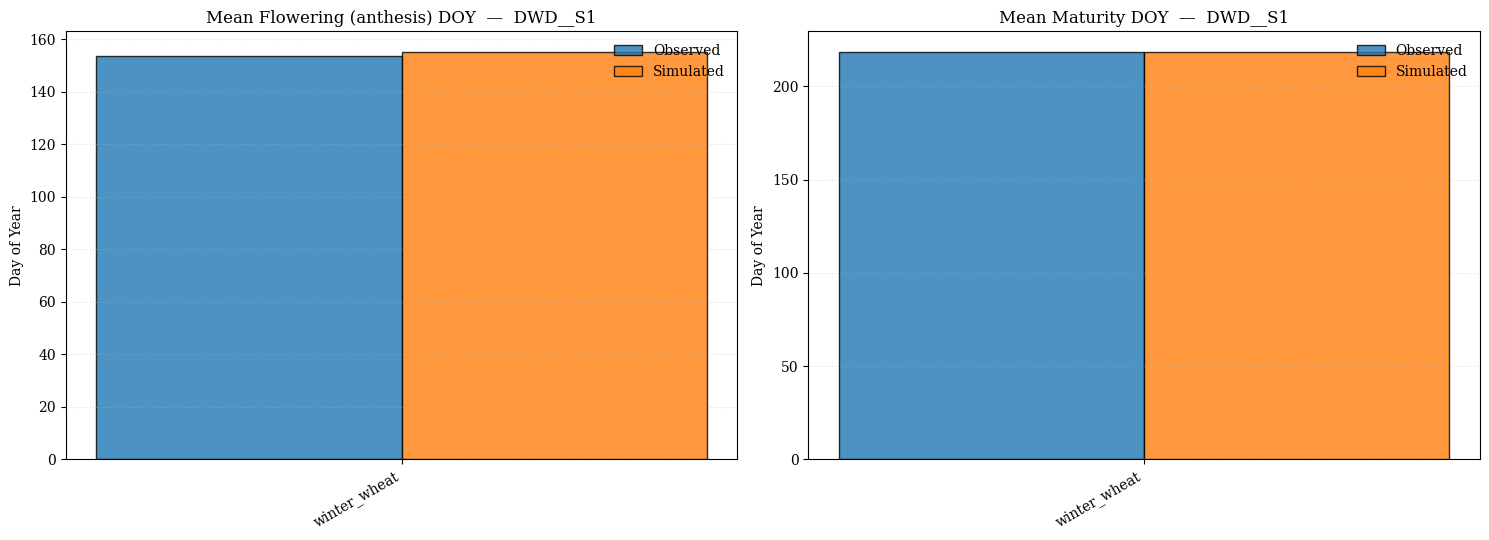

In [9]:
summary = (
    all_df.groupby("crop")
    .agg(
        flowering_obs=("flowering_doy", "mean"),
        flowering_sim=("flowering_doy_sim", "mean"),
        maturity_obs=("maturity_doy", "mean"),
        maturity_sim=("maturity_doy_sim", "mean"),
    )
    .reindex([c for c in CROPS if c in comparison])
)

crops = summary.index.tolist()
x = np.arange(len(crops))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=False)

for ax, stage, title in [
    (axes[0], "flowering", "Flowering (anthesis)"),
    (axes[1], "maturity", "Maturity"),
]:
    ax.bar(x - width / 2, summary[f"{stage}_obs"], width,
           label="Observed", edgecolor="k", alpha=0.8)
    ax.bar(x + width / 2, summary[f"{stage}_sim"], width,
           label="Simulated", edgecolor="k", alpha=0.8)
    ax.set_title(f"Mean {title} DOY  —  {SIM_NAME}")
    ax.set_ylabel("Day of Year")
    ax.set_xticks(x)
    ax.set_xticklabels(crops, rotation=30, ha="right")
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## Observed vs simulated scatter (1:1)

One panel per crop. Points on the dashed 1:1 line are a perfect match; the RMSE
is annotated for each stage. Points are **coloured by local density** (number of
points in the surrounding 2-D bin, log scale) so overlapping clusters are visible
despite the tens of thousands of location-years. Marker shape distinguishes the
stage (circle = flowering, triangle = maturity); the colour bar is shared across
crops so densities are comparable.


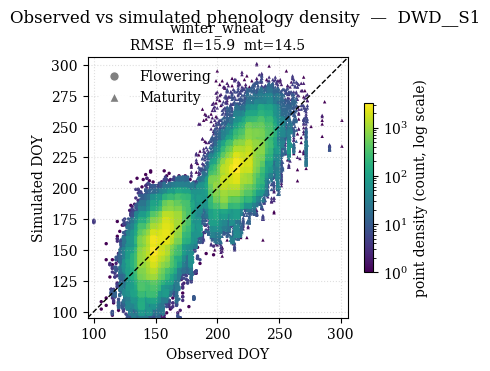

In [10]:
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D


def point_density(x, y, bins=60):
    """Local point count for each (x, y) via a fast 2-D histogram lookup."""
    H, xe, ye = np.histogram2d(x, y, bins=bins)
    ix = np.clip(np.digitize(x, xe) - 1, 0, H.shape[0] - 1)
    iy = np.clip(np.digitize(y, ye) - 1, 0, H.shape[1] - 1)
    return H[ix, iy]


# Pass 1: compute per-point density for each crop (flowering + maturity stacked
# so a panel shares one colour scale). A global max keeps all panels comparable.
dens = {}
for crop, df in comparison.items():
    x = np.r_[df["flowering_doy"].values, df["maturity_doy"].values]
    y = np.r_[df["flowering_doy_sim"].values, df["maturity_doy_sim"].values]
    dens[crop] = point_density(x, y)
norm = LogNorm(vmin=1, vmax=max(d.max() for d in dens.values()))

# Pass 2: plot density-coloured scatter, one panel per crop.
ncrops = len(comparison)
fig, axes = plt.subplots(1, ncrops, figsize=(4.2 * ncrops, 4.4), squeeze=False)
axes = axes[0]

sc = None
for ax, (crop, df) in zip(axes, comparison.items()):
    xf, yf = df["flowering_doy"].values, df["flowering_doy_sim"].values
    xm, ym = df["maturity_doy"].values, df["maturity_doy_sim"].values
    d_fl, d_mt = dens[crop][: len(xf)], dens[crop][len(xf):]

    for xx, yy, dd, marker in [(xf, yf, d_fl, "o"), (xm, ym, d_mt, "^")]:
        order = np.argsort(dd)  # draw densest points on top
        sc = ax.scatter(xx[order], yy[order], c=dd[order], s=6, marker=marker,
                        cmap="viridis", norm=norm, linewidths=0)

    lo = min(df["flowering_doy"].min(), df["maturity_doy"].min()) - 5
    hi = max(df["maturity_doy"].max(), df["maturity_doy_sim"].max()) + 5
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")

    m = phenology_loss(df)
    ax.set_title(
        f"{crop}\nRMSE  fl={m['flowering_rmse']:.1f}  mt={m['maturity_rmse']:.1f}",
        fontsize=10,
    )
    ax.set_xlabel("Observed DOY")
    ax.grid(linestyle=":", alpha=0.4)

axes[0].set_ylabel("Simulated DOY")

# Stage legend (marker shape) + a shared density colour bar.
stage_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markersize=7, label="Flowering"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="gray",
           markersize=7, label="Maturity"),
]
axes[0].legend(handles=stage_handles, frameon=False, loc="upper left")
fig.colorbar(sc, ax=list(axes), shrink=0.5,
             label="point density (count, log scale)")
fig.suptitle(f"Observed vs simulated phenology density  —  {SIM_NAME}", y=0.9)
plt.show()

## Year-wise trends per crop

For each crop, mean flowering and maturity DOY per harvest year (observed vs
simulated, with ±1 std error bars). This shows how well the simulation tracks
inter-annual variability.


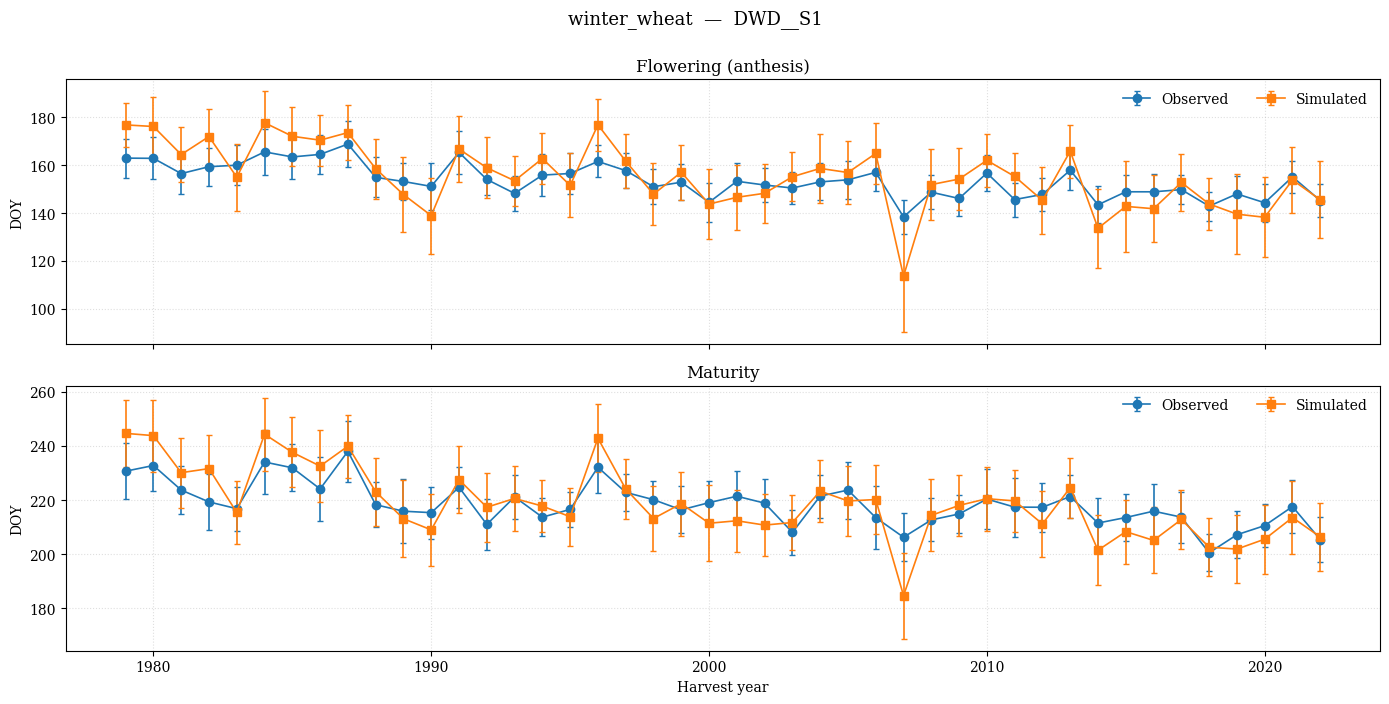

In [11]:
def yearwise_stats(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby("harvest_year")
    stats = pd.DataFrame(
        {
            "flowering_obs_mean": g["flowering_doy"].mean(),
            "flowering_obs_std": g["flowering_doy"].std(),
            "flowering_sim_mean": g["flowering_doy_sim"].mean(),
            "flowering_sim_std": g["flowering_doy_sim"].std(),
            "maturity_obs_mean": g["maturity_doy"].mean(),
            "maturity_obs_std": g["maturity_doy"].std(),
            "maturity_sim_mean": g["maturity_doy_sim"].mean(),
            "maturity_sim_std": g["maturity_doy_sim"].std(),
        }
    ).reset_index()
    return stats


for crop, df in comparison.items():
    stats = yearwise_stats(df)
    years = stats["harvest_year"]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    for ax, stage, title in [
        (axes[0], "flowering", "Flowering (anthesis)"),
        (axes[1], "maturity", "Maturity"),
    ]:
        ax.errorbar(years, stats[f"{stage}_obs_mean"], yerr=stats[f"{stage}_obs_std"],
                    marker="o", capsize=2, linewidth=1.2, label="Observed")
        ax.errorbar(years, stats[f"{stage}_sim_mean"], yerr=stats[f"{stage}_sim_std"],
                    marker="s", capsize=2, linewidth=1.2, label="Simulated")
        ax.set_ylabel("DOY")
        ax.set_title(title)
        ax.grid(linestyle=":", alpha=0.4)
        ax.legend(ncol=2, frameon=False)

    axes[1].set_xlabel("Harvest year")
    fig.suptitle(f"{crop}  —  {SIM_NAME}", y=1.0, fontsize=13)
    plt.tight_layout()
    plt.show()

## State-wise comparison per crop (optional)

Mean flowering and maturity DOY by federal state. State names come from the
observed phenology table.


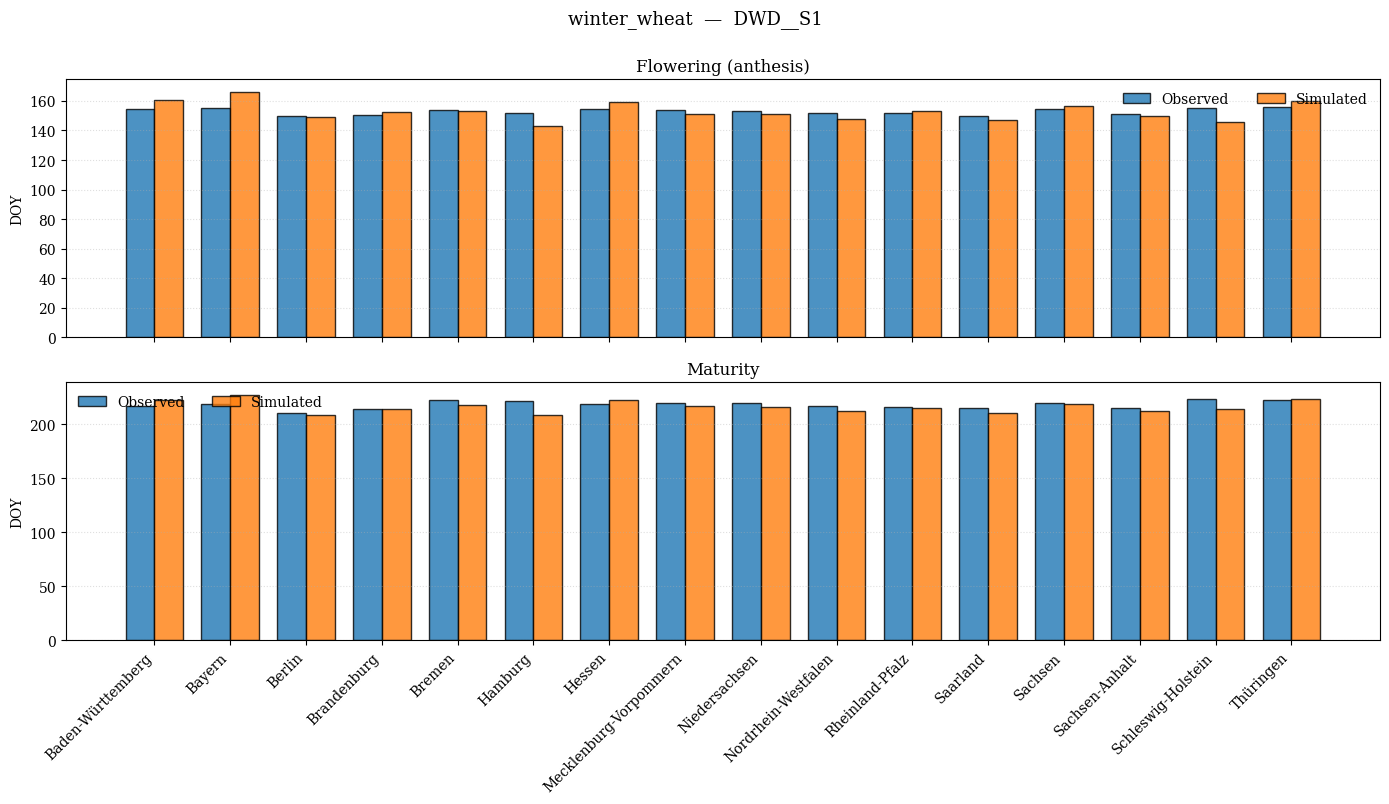

In [12]:
for crop, df in comparison.items():
    st = (
        df.groupby("STATE_NAME")
        .agg(
            flowering_obs=("flowering_doy", "mean"),
            flowering_sim=("flowering_doy_sim", "mean"),
            maturity_obs=("maturity_doy", "mean"),
            maturity_sim=("maturity_doy_sim", "mean"),
        )
        .reset_index()
        .sort_values("STATE_NAME")
    )
    states = st["STATE_NAME"]
    x = np.arange(len(states))
    width = 0.38

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    for ax, stage, title in [
        (axes[0], "flowering", "Flowering (anthesis)"),
        (axes[1], "maturity", "Maturity"),
    ]:
        ax.bar(x - width / 2, st[f"{stage}_obs"], width, label="Observed",
               edgecolor="k", alpha=0.8)
        ax.bar(x + width / 2, st[f"{stage}_sim"], width, label="Simulated",
               edgecolor="k", alpha=0.8)
        ax.set_ylabel("DOY")
        ax.set_title(title)
        ax.grid(axis="y", linestyle=":", alpha=0.4)
        ax.legend(ncol=2, frameon=False)

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(states, rotation=45, ha="right")
    fig.suptitle(f"{crop}  —  {SIM_NAME}", y=1.0, fontsize=13)
    plt.tight_layout()
    plt.show()